# Extreme Value Analysis Tutorial

This notebook demonstrates how to use the `ExtremesAnalyzer` class for extreme value analysis, including return period calculations, block maxima extraction, and Peaks Over Threshold (POT) analysis.

## Overview

`ExtremesAnalyzer` is designed to:
- Calculate return periods and return values for extreme events
- Extract block maxima (annual, monthly, seasonal)
- Perform Peaks Over Threshold (POT) analysis with declustering
- Fit extreme value distributions (GEV, Gumbel, Weibull, GPD)
- Visualize return level plots
- Handle flexible time series formats (pandas, datetime64, numeric arrays)

## Setup and Data Generation

Let's start by importing the necessary libraries and generating sample wind speed data with realistic temporal structure.

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import magica as ma
from magica.core import DataProcessor, ExtremesAnalyzer

# Set random seed for reproducibility
np.random.seed(42)

# Generate 10 years of daily wind speed data
start_date = '2010-01-01'
end_date = '2019-12-31'
dates = pd.date_range(start=start_date, end=end_date, freq='D')
n_samples = len(dates)

# Base wind speeds (Weibull-like distribution)
base_wind = np.random.weibull(2.5, n_samples) * 6 + 2

# Add seasonal variation (stronger winds in winter)
day_of_year = dates.dayofyear.values
seasonal_factor = 1 + 0.3 * np.cos(2 * np.pi * (day_of_year - 15) / 365)  # Peak in winter
wind_speeds = base_wind * seasonal_factor

# Add realistic storm events with persistence (winds stay high for several days)
n_storms = 15
storm_starts = np.random.choice(n_samples - 7, n_storms, replace=False)  # Ensure room for storm duration

for storm_start in storm_starts:
    # Each storm has a random duration between 2-5 days
    storm_duration = np.random.randint(2, 6)
    
    # Storm intensity peaks in the middle and tapers off
    peak_intensity = np.random.uniform(12, 20)
    
    for day in range(storm_duration):
        if storm_start + day < n_samples:
            # Create a bell-shaped intensity profile for the storm
            # Peak in the middle, lower at edges
            relative_position = day / (storm_duration - 1) if storm_duration > 1 else 0.5
            intensity_factor = np.exp(-4 * (relative_position - 0.5)**2)  # Gaussian-like shape
            
            # Add wind increase for this day
            wind_speeds[storm_start + day] += peak_intensity * intensity_factor
            
            # Add some random variation
            wind_speeds[storm_start + day] += np.random.normal(0, 1)

# Create pandas Series with datetime index
wind_series = pd.Series(wind_speeds, index=dates, name='Wind Speed (m/s)')

print(f"Generated {n_samples} daily wind speed measurements ({len(dates)/365:.1f} years)")
print(f"Date range: {dates[0].date()} to {dates[-1].date()}")
print(f"Min: {wind_speeds.min():.2f} m/s")
print(f"Max: {wind_speeds.max():.2f} m/s")
print(f"Mean: {wind_speeds.mean():.2f} m/s")
print(f"Std: {wind_speeds.std():.2f} m/s")
print(f"\n⛈️  Simulated {n_storms} storm events with 2-5 day durations")

Generated 3652 daily wind speed measurements (10.0 years)
Date range: 2010-01-01 to 2019-12-31
Min: 1.86 m/s
Max: 31.01 m/s
Mean: 7.44 m/s
Std: 3.08 m/s

⛈️  Simulated 15 storm events with 2-5 day durations


## Visualizing the Time Series

Let's look at the complete time series and identify extreme events.

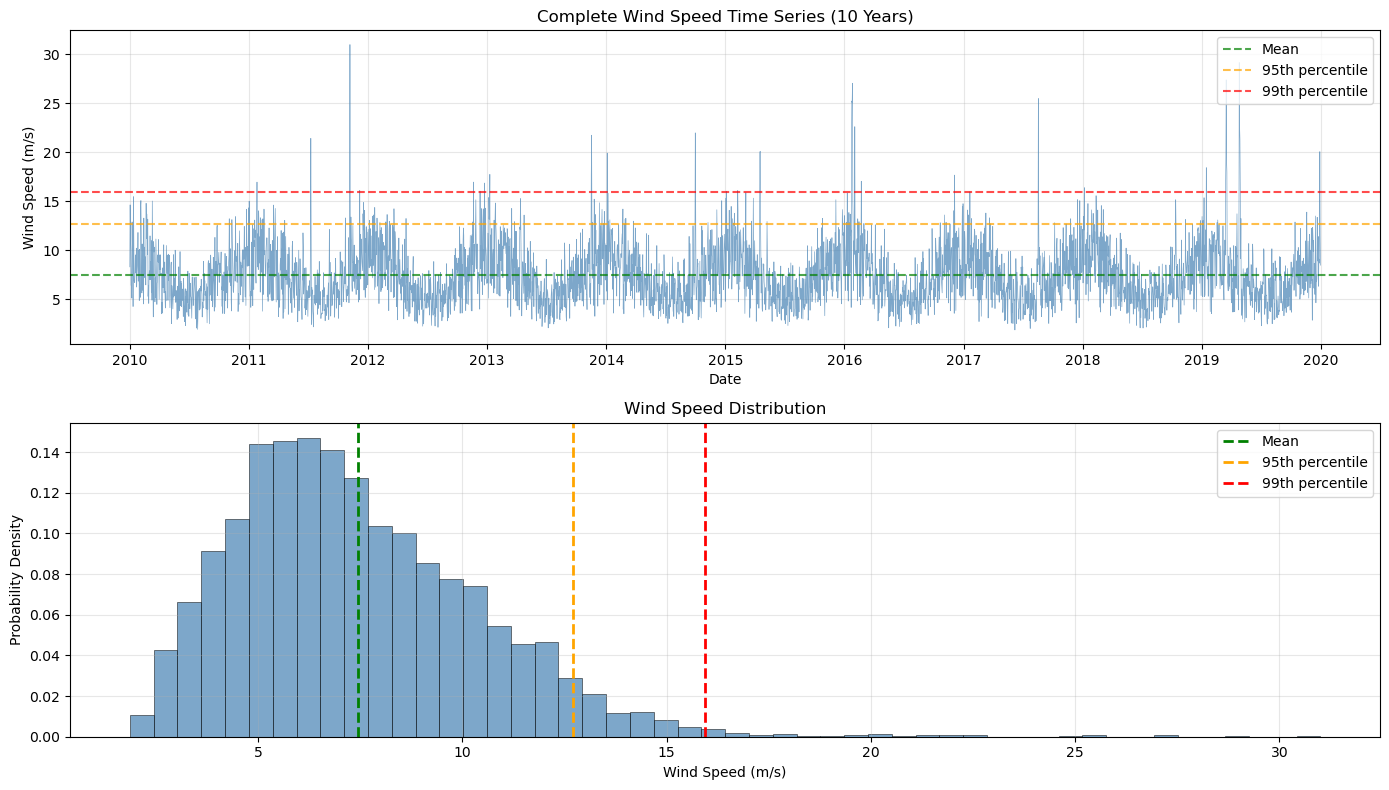


Extreme value thresholds:
Mean: 7.44 m/s
95th percentile: 12.71 m/s
99th percentile: 15.93 m/s
Maximum: 31.01 m/s


In [50]:
# Plot the complete time series
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Full time series
ax1.plot(dates, wind_speeds, linewidth=0.5, alpha=0.7, color='steelblue')
ax1.axhline(wind_speeds.mean(), color='green', linestyle='--', linewidth=1.5, label='Mean', alpha=0.7)
ax1.axhline(np.percentile(wind_speeds, 95), color='orange', linestyle='--', linewidth=1.5, label='95th percentile', alpha=0.7)
ax1.axhline(np.percentile(wind_speeds, 99), color='red', linestyle='--', linewidth=1.5, label='99th percentile', alpha=0.7)
ax1.set_xlabel('Date')
ax1.set_ylabel('Wind Speed (m/s)')
ax1.set_title('Complete Wind Speed Time Series (10 Years)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Histogram
ax2.hist(wind_speeds, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
ax2.axvline(wind_speeds.mean(), color='green', linestyle='--', linewidth=2, label='Mean')
ax2.axvline(np.percentile(wind_speeds, 95), color='orange', linestyle='--', linewidth=2, label='95th percentile')
ax2.axvline(np.percentile(wind_speeds, 99), color='red', linestyle='--', linewidth=2, label='99th percentile')
ax2.set_xlabel('Wind Speed (m/s)')
ax2.set_ylabel('Probability Density')
ax2.set_title('Wind Speed Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nExtreme value thresholds:")
print(f"Mean: {wind_speeds.mean():.2f} m/s")
print(f"95th percentile: {np.percentile(wind_speeds, 95):.2f} m/s")
print(f"99th percentile: {np.percentile(wind_speeds, 99):.2f} m/s")
print(f"Maximum: {wind_speeds.max():.2f} m/s")

## Basic Usage: Creating an ExtremesAnalyzer

The `ExtremesAnalyzer` can be created from a `DataProcessor` using the `get_extremes_analyzer()` method. It automatically handles pandas Series with datetime indices.

In [51]:
# Load data using MagicA's DataProcessor
# The pandas Series with datetime index will be automatically preserved
processor = ma.read_data(wind_series)
print(f"Loaded data: {processor}")

# Create ExtremesAnalyzer (time_unit='years' for return periods in years)
extremes = processor.get_extremes_analyzer(time_unit='years')
print(f"\nCreated ExtremesAnalyzer: {extremes}")

# Check the time span
print(f"Time span: {extremes.time_span:.2f} years")
print(f"Number of observations: {len(extremes.data)}")

Loaded data: DataProcessor(length=3652, dtype=float64)

Created ExtremesAnalyzer: ExtremesAnalyzer(n_points=3652, time_span=10.0 years)
Time span: 10.00 years
Number of observations: 3652


## Block Maxima Approach: Generalized Extreme Value (GEV) Distribution

The Block Maxima method extracts the maximum value from fixed time blocks (e.g., annual maxima) and fits a GEV distribution. This is the classical approach in extreme value theory.

In [52]:
# Extract annual maxima
annual_maxima, years = extremes.extract_block_maxima(block_size='Y', method='max')
print(f"Annual Maxima Analysis:")
print(f"Number of years: {len(annual_maxima)}")
print(f"\nAnnual maximum wind speeds:")
for year, max_wind in zip(years, annual_maxima):
    print(f"  {year.year}: {max_wind:.2f} m/s")
print(f"\nStatistics of annual maxima:")
maxima_values = list(annual_maxima)
print(f"Mean: {np.mean(maxima_values):.2f} m/s")
print(f"Std: {np.std(maxima_values):.2f} m/s")
print(f"Min: {np.min(maxima_values):.2f} m/s")
print(f"Max: {np.max(maxima_values):.2f} m/s")

Annual Maxima Analysis:
Number of years: 10

Annual maximum wind speeds:
  2010: 15.47 m/s
  2011: 31.01 m/s
  2012: 16.96 m/s
  2013: 21.75 m/s
  2014: 21.99 m/s
  2015: 20.11 m/s
  2016: 27.06 m/s
  2017: 25.49 m/s
  2018: 16.39 m/s
  2019: 29.17 m/s

Statistics of annual maxima:
Mean: 22.54 m/s
Std: 5.20 m/s
Min: 15.47 m/s
Max: 31.01 m/s


/home/daniloceano/Documents/Programs_and_scripts/MagicA/magica/core/extremes_analyzer.py:460: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  resampled = series.resample(block_size).max()


In [53]:
# Create a new processor with annual maxima
maxima_processor = ma.read_data(np.array(maxima_values))

# Create ExtremesAnalyzer and fit GEV distribution directly
# Note: No need to specify time_unit since each observation already represents 1 year
maxima_extremes = maxima_processor.get_extremes_analyzer()
maxima_extremes.fit_distribution('genextreme')

# Get fitted parameters
params = maxima_extremes.fitted_params
print(f"\nFitted GEV Distribution Parameters:")
print(f"Shape (ξ): {params[0]:.4f}")
print(f"Location (μ): {params[1]:.4f}")
print(f"Scale (σ): {params[2]:.4f}")

# Interpret the shape parameter
if params[0] > 0.1:
    print(f"\nInterpretation: Fréchet family (heavy-tailed, bounded below)")
elif params[0] < -0.1:
    print(f"\nInterpretation: Weibull family (short-tailed, bounded above)")
else:
    print(f"\nInterpretation: Gumbel family (exponential tails)")

/home/daniloceano/Documents/Programs_and_scripts/MagicA/magica/core/extremes_analyzer.py:113: UserWarning: No time information provided. Assuming uniform time spacing. Return periods will be in units of observation count.
  warnings.warn(



Fitted GEV Distribution Parameters:
Shape (ξ): 0.2926
Location (μ): 20.7297
Scale (σ): 5.0439

Interpretation: Fréchet family (heavy-tailed, bounded below)


## Return Period and Return Value Analysis

Now let's calculate return values for different return periods (e.g., 10-year, 50-year, 100-year wind speeds).

**Important Note on Workflow:**
- When working with block maxima (e.g., annual maxima), each data point already represents one time unit (e.g., 1 year)
- The `ExtremesAnalyzer` can fit distributions directly using `fit_distribution()`
- No need to fit the distribution on the `DataProcessor` first
-  The `time_unit` parameter is mainly for the original time series, not for the extracted maxima

In [54]:
# Calculate return values for various return periods
# The maxima_extremes analyzer already has the fitted distribution
return_periods = [2, 5, 10, 20, 50, 100]

print("Return Period Analysis (Block Maxima / GEV):")
print("=" * 60)
print(f"{'Return Period':<20} {'Return Value (m/s)':<20} {'Design Use'}")
print("-" * 60)

for T in return_periods:
    rv = maxima_extremes.return_value(T)
    
    # Suggest design use based on return period
    if T <= 5:
        design_use = "Operational limits"
    elif T <= 25:
        design_use = "Standard structures"
    elif T <= 50:
        design_use = "Important structures"
    else:
        design_use = "Critical infrastructure"
    
    print(f"{T} years{'':<13} {rv:.2f}{'':<15} {design_use}")

print("\n💡 Interpretation:")
print("   A 50-year return value has a 2% probability of being exceeded in any given year.")
print("   Over a 50-year period, there's approximately a 63.4% chance of exceeding this value.")

Return Period Analysis (Block Maxima / GEV):
Return Period        Return Value (m/s)   Design Use
------------------------------------------------------------
2 years              22.48                Operational limits
5 years              26.85                Operational limits
10 years              29.04                Standard structures
20 years              30.74                Standard structures
50 years              32.46                Important structures
100 years              33.48                Critical infrastructure

💡 Interpretation:
   A 50-year return value has a 2% probability of being exceeded in any given year.
   Over a 50-year period, there's approximately a 63.4% chance of exceeding this value.


In [55]:
# Calculate return periods for specific wind speed thresholds
threshold_speeds = [22, 24, 26, 28]

print("\nReturn Period for Specific Wind Speed Thresholds:")
print("=" * 60)
print(f"{'Wind Speed (m/s)':<20} {'Return Period (years)':<25} {'Probability/year'}")
print("-" * 60)

for speed in threshold_speeds:
    T = maxima_extremes.return_period(speed)
    prob = 1.0 / T if T > 0 else 0
    print(f"{speed}{'':<16} {T:.2f}{'':<21} {prob:.4f} ({prob*100:.2f}%)")

print("\n💡 Example: A wind speed of 25 m/s has a return period of X years,")
print("   meaning it's expected to be exceeded once every X years on average.")


Return Period for Specific Wind Speed Thresholds:
Wind Speed (m/s)     Return Period (years)     Probability/year
------------------------------------------------------------
22                 1.86                      0.5369 (53.69%)
24                 2.59                      0.3857 (38.57%)
26                 4.00                      0.2497 (24.97%)
28                 7.01                      0.1426 (14.26%)

💡 Example: A wind speed of 25 m/s has a return period of X years,
   meaning it's expected to be exceeded once every X years on average.


## Visualization: Return Level Plot

The return level plot is a fundamental diagnostic tool in extreme value analysis, showing both empirical and theoretical return levels.

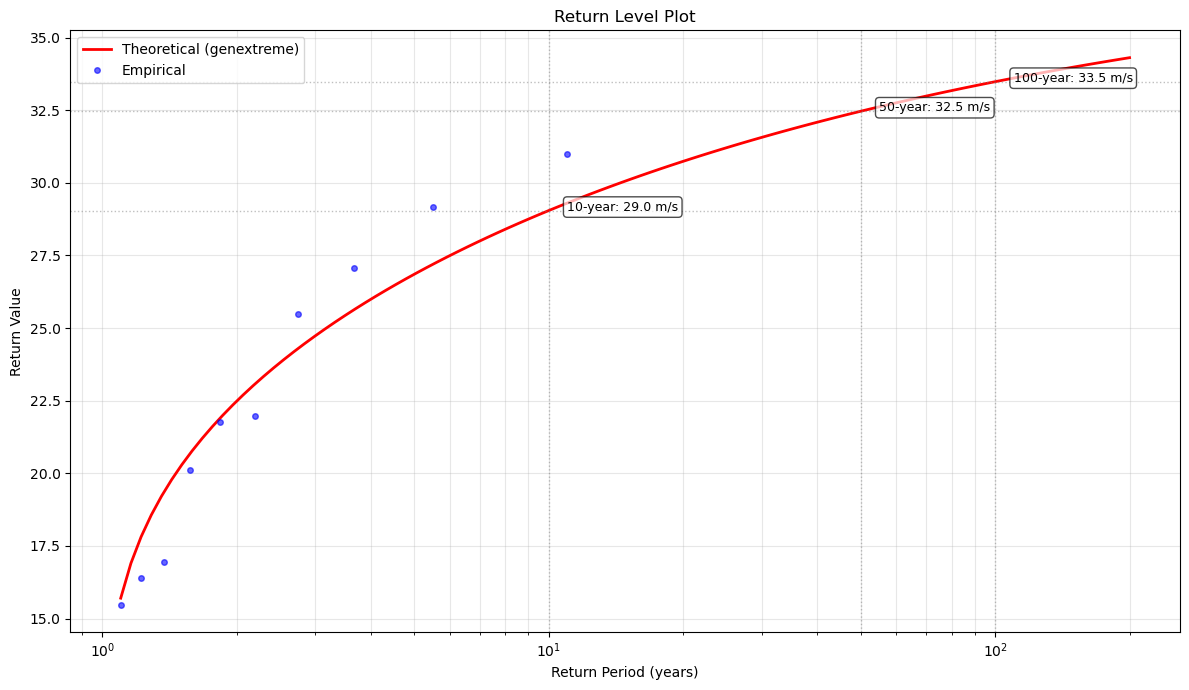


📊 Return Level Plot Interpretation:
   • Blue points: Empirical return levels from observed annual maxima
   • Red line: Theoretical return levels from fitted GEV distribution
   • Shaded area: 95% confidence interval (if calculated)
   • Good agreement indicates the GEV model fits well
   • Deviations at high return periods are common due to extrapolation


In [56]:
# Create return level plot
fig, ax = plt.subplots(figsize=(12, 7))

maxima_extremes.plot_return_levels(
    ax=ax,
    return_periods=np.logspace(np.log10(1.1), np.log10(200), 100),  # From 1.1 to 200 years
    confidence_level=0.95,
)

# Add reference lines for common design return periods
design_periods = [10, 50, 100]
for T in design_periods:
    rv = maxima_extremes.return_value(T)
    ax.axhline(rv, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax.axvline(T, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax.text(T * 1.1, rv, f'{T}-year: {rv:.1f} m/s', fontsize=9, 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n📊 Return Level Plot Interpretation:")
print("   • Blue points: Empirical return levels from observed annual maxima")
print("   • Red line: Theoretical return levels from fitted GEV distribution")
print("   • Shaded area: 95% confidence interval (if calculated)")
print("   • Good agreement indicates the GEV model fits well")
print("   • Deviations at high return periods are common due to extrapolation")

## Peaks Over Threshold (POT) Approach: Generalized Pareto Distribution (GPD)

The POT method identifies all values exceeding a high threshold and fits a GPD to the exceedances. This approach uses more data than block maxima and can be more efficient.

In [57]:
# Choose threshold (e.g., 95th percentile)
threshold = np.percentile(wind_speeds, 95)
print(f"Threshold for POT analysis: {threshold:.2f} m/s (95th percentile)")

# Extract peaks over threshold with declustering
# min_separation ensures peaks are independent (at least 3 days apart)
peaks, peak_times = extremes.peaks_over_threshold(
    threshold=threshold,
    min_separation=3  # days
)

print(f"\nPeaks Over Threshold Analysis:")
print(f"Number of peaks identified: {len(peaks)}")
print(f"Average exceedance rate: {len(peaks) / extremes.time_span:.2f} peaks/year")
print(f"\nFirst 10 peaks:")
for i, (peak, time) in enumerate(zip(peaks[:10], peak_times[:10])):
    print(f"  {i+1}. {time}: {peak:.2f} m/s (exceedance: {peak - threshold:.2f} m/s)")

Threshold for POT analysis: 12.71 m/s (95th percentile)

Peaks Over Threshold Analysis:
Number of peaks identified: 142
Average exceedance rate: 14.21 peaks/year

First 10 peaks:
  1. 2010-01-02 00:00:00: 14.64 m/s (exceedance: 1.92 m/s)
  2. 2010-01-08 00:00:00: 12.89 m/s (exceedance: 0.18 m/s)
  3. 2010-01-12 00:00:00: 15.47 m/s (exceedance: 2.76 m/s)
  4. 2010-02-03 00:00:00: 14.48 m/s (exceedance: 1.77 m/s)
  5. 2010-02-13 00:00:00: 13.29 m/s (exceedance: 0.58 m/s)
  6. 2010-02-20 00:00:00: 14.80 m/s (exceedance: 2.09 m/s)
  7. 2010-02-23 00:00:00: 12.72 m/s (exceedance: 0.01 m/s)
  8. 2010-03-11 00:00:00: 15.03 m/s (exceedance: 2.32 m/s)
  9. 2010-11-02 00:00:00: 13.22 m/s (exceedance: 0.51 m/s)
  10. 2010-11-10 00:00:00: 13.13 m/s (exceedance: 0.42 m/s)


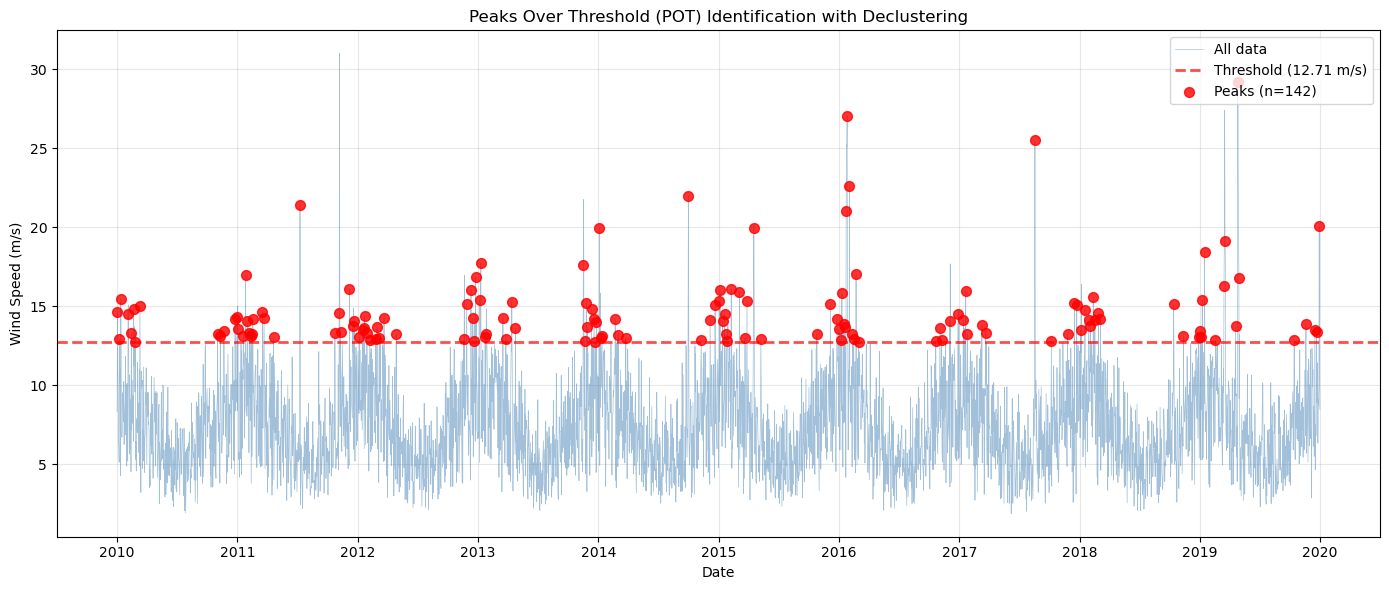


💡 Declustering ensures peaks are independent (min 3 days apart)
   This avoids counting multiple observations from the same storm event.


In [58]:
# Visualize the POT extraction
fig, ax = plt.subplots(figsize=(14, 6))

# Plot full time series
ax.plot(dates, wind_speeds, linewidth=0.5, alpha=0.5, color='steelblue', label='All data')

# Highlight threshold
ax.axhline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.2f} m/s)', alpha=0.7)

# Mark identified peaks
ax.scatter(peak_times, peaks, color='red', s=50, zorder=5, label=f'Peaks (n={len(peaks)})', alpha=0.8)

ax.set_xlabel('Date')
ax.set_ylabel('Wind Speed (m/s)')
ax.set_title('Peaks Over Threshold (POT) Identification with Declustering')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Declustering ensures peaks are independent (min {3} days apart)")
print(f"   This avoids counting multiple observations from the same storm event.")

In [59]:
# Fit GPD to exceedances (peaks - threshold)
exceedances = peaks - threshold

exceedance_processor = ma.read_data(exceedances)

# Create ExtremesAnalyzer for exceedances
# We specify time_unit='years' here because we'll need it for POT return value calculations
# (which depend on the exceedance rate per year from the original series)
pot_extremes = exceedance_processor.get_extremes_analyzer(time_unit='years')

# Fit GPD (genpareto in SciPy) directly on the extremes analyzer
pot_extremes.fit_distribution('genpareto')

# Get fitted parameters
gpd_params = pot_extremes.fitted_params
print(f"Fitted GPD Parameters (for exceedances):")
print(f"Shape (ξ): {gpd_params[0]:.4f}")
print(f"Location: {gpd_params[1]:.4f}")
print(f"Scale (σ): {gpd_params[2]:.4f}")

# Interpret the shape parameter
if gpd_params[0] > 0.1:
    print(f"\nInterpretation: Heavy-tailed distribution (higher probability of extremes)")
elif gpd_params[0] < -0.1:
    print(f"\nInterpretation: Short-tailed distribution (finite upper bound)")
else:
    print(f"\nInterpretation: Exponential-like tails")

Fitted GPD Parameters (for exceedances):
Shape (ξ): 0.2779
Location: 0.0107
Scale (σ): 1.4736

Interpretation: Heavy-tailed distribution (higher probability of extremes)


/home/daniloceano/Documents/Programs_and_scripts/MagicA/magica/core/extremes_analyzer.py:113: UserWarning: No time information provided. Assuming uniform time spacing. Return periods will be in units of observation count.
  warnings.warn(


## POT Return Value Calculation

For POT analysis, return values must account for the exceedance rate and threshold.

In [60]:
# Calculate POT-based return values
# Return value = threshold + GPD quantile adjusted for exceedance rate

exceedance_rate = len(peaks) / extremes.time_span  # peaks per year

print("Return Period Analysis (POT / GPD):")
print("=" * 60)
print(f"Exceedance rate: {exceedance_rate:.2f} peaks/year")
print(f"Threshold: {threshold:.2f} m/s\n")
print(f"{'Return Period':<20} {'Return Value (m/s)':<20} {'Exceedance Level'}")
print("-" * 60)

for T in return_periods:
    # For POT, the return period relates to the probability of exceeding the threshold
    # P(X > x | X > u) = (1 - F_GPD(x-u))
    # Return level: x = u + scale * ((λT)^ξ - 1) / ξ, where λ is exceedance rate
    
    # Using the fitted GPD to calculate the quantile
    prob = 1.0 / (exceedance_rate * T)  # Probability in the GPD scale
    if prob < 1.0:
        exceedance_quantile = pot_extremes.ppf(1 - prob)
        rv_pot = threshold + exceedance_quantile
    else:
        rv_pot = np.nan
    
    if not np.isnan(rv_pot):
        exceedance = rv_pot - threshold
        print(f"{T} years{'':<13} {rv_pot:.2f}{'':<15} +{exceedance:.2f} m/s")
    else:
        print(f"{T} years{'':<13} {'N/A':<20} {'N/A'}")

print("\n💡 POT return values account for:")
print("   • The threshold level (base wind speed)")
print("   • The exceedance distribution (GPD)")
print("   • The rate of threshold exceedances")

Return Period Analysis (POT / GPD):
Exceedance rate: 14.21 peaks/year
Threshold: 12.71 m/s

Return Period        Return Value (m/s)   Exceedance Level
------------------------------------------------------------
2 years              20.86                +8.15 m/s
5 years              24.76                +12.05 m/s
10 years              28.44                +15.73 m/s
20 years              32.91                +20.20 m/s
50 years              40.30                +27.59 m/s
100 years              47.29                +34.57 m/s

💡 POT return values account for:
   • The threshold level (base wind speed)
   • The exceedance distribution (GPD)
   • The rate of threshold exceedances


## Comparing Block Maxima vs POT Approaches

Let's compare the return value estimates from both methods.

## Advanced Declustering: Event-Wise vs Time-Based Separation

When extracting peaks over threshold, we need to ensure independence between events. There are two main approaches:

1. **Time-based separation**: Keep peaks separated by a minimum time interval (e.g., 3 days)
2. **Event-wise declustering**: Identify consecutive periods above threshold as single events and extract only the maximum from each event

Let's compare these approaches and see how different thresholds affect the number and characteristics of identified events.

In [61]:
# Compare different declustering methods at 90th percentile
threshold_90 = np.percentile(wind_speeds, 90)

# Method 1: No declustering (all exceedances)
peaks_all, times_all = extremes.peaks_over_threshold(threshold=threshold_90)

# Method 2: Time-based separation (3 days)
peaks_3days, times_3days = extremes.peaks_over_threshold(
    threshold=threshold_90, 
    min_separation=3
)

# Method 3: Event-wise (consecutive days as single event)
peaks_eventwise, times_eventwise = extremes.peaks_over_threshold(
    threshold=threshold_90, 
    event_wise=True
)

print("Declustering Method Comparison (90th percentile threshold)")
print("=" * 70)
print(f"Threshold: {threshold_90:.2f} m/s")
print(f"\n{'Method':<25} {'# Peaks':<12} {'Mean Peak':<12} {'Max Peak'}")
print("-" * 70)
print(f"{'All exceedances':<25} {len(peaks_all):<12} {np.mean(peaks_all):<12.2f} {np.max(peaks_all):.2f}")
print(f"{'3-day separation':<25} {len(peaks_3days):<12} {np.mean(peaks_3days):<12.2f} {np.max(peaks_3days):.2f}")
print(f"{'Event-wise':<25} {len(peaks_eventwise):<12} {np.mean(peaks_eventwise):<12.2f} {np.max(peaks_eventwise):.2f}")

print(f"\n💡 Event-wise declustering identified {len(peaks_eventwise)} independent storm events")
print(f"   compared to {len(peaks_3days)} peaks with 3-day separation")
print(f"   and {len(peaks_all)} total exceedances.")

Declustering Method Comparison (90th percentile threshold)
Threshold: 11.48 m/s

Method                    # Peaks      Mean Peak    Max Peak
----------------------------------------------------------------------
All exceedances           366          13.59        31.01
3-day separation          253          13.30        29.17
Event-wise                276          13.61        31.01

💡 Event-wise declustering identified 276 independent storm events
   compared to 253 peaks with 3-day separation
   and 366 total exceedances.


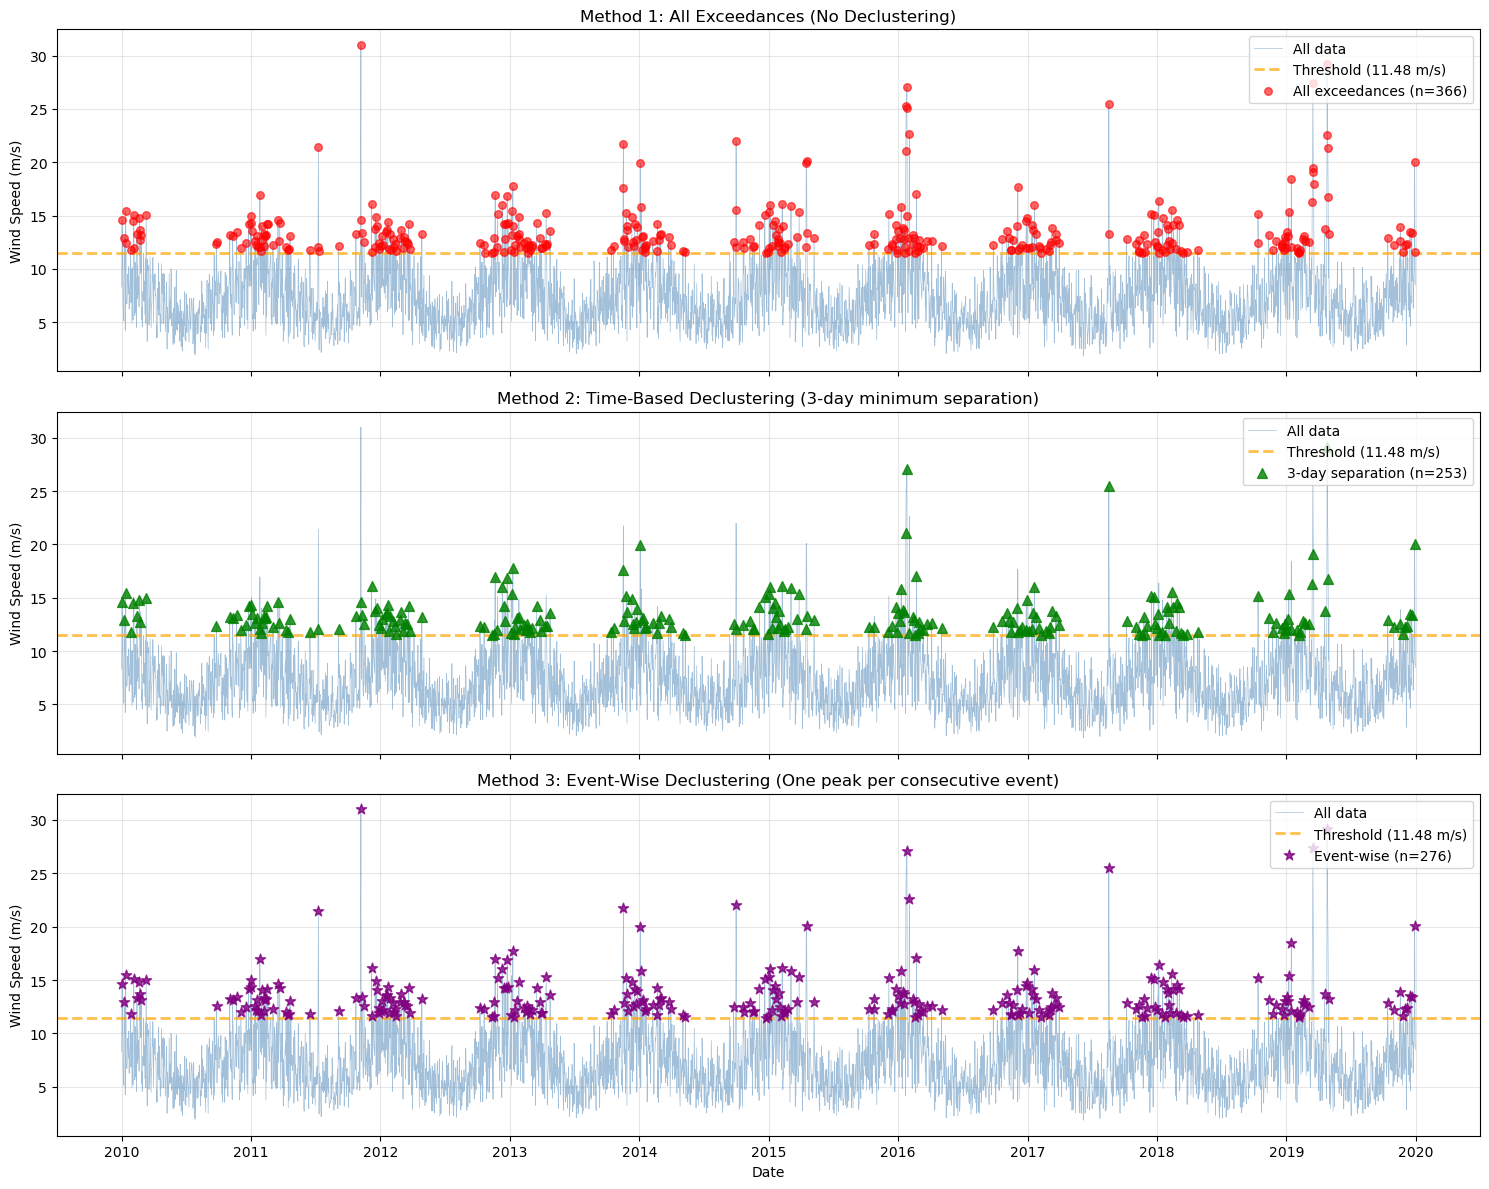


📊 Interpretation:
   • Top: Shows all days exceeding threshold (may include multiple days from same storm)
   • Middle: Keeps peaks at least 3 days apart (may still miss some storm clusters)
   • Bottom: One peak per storm event (consecutive days grouped together)


In [62]:
# Visualize the difference between declustering methods
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Plot 1: All exceedances
ax = axes[0]
ax.plot(dates, wind_speeds, linewidth=0.5, alpha=0.5, color='steelblue', label='All data')
ax.axhline(threshold_90, color='orange', linestyle='--', linewidth=2, 
           label=f'Threshold ({threshold_90:.2f} m/s)', alpha=0.7)
ax.scatter(times_all, peaks_all, color='red', s=30, zorder=5, 
          label=f'All exceedances (n={len(peaks_all)})', alpha=0.6)
ax.set_ylabel('Wind Speed (m/s)')
ax.set_title('Method 1: All Exceedances (No Declustering)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Plot 2: 3-day separation
ax = axes[1]
ax.plot(dates, wind_speeds, linewidth=0.5, alpha=0.5, color='steelblue', label='All data')
ax.axhline(threshold_90, color='orange', linestyle='--', linewidth=2, 
           label=f'Threshold ({threshold_90:.2f} m/s)', alpha=0.7)
ax.scatter(times_3days, peaks_3days, color='green', s=50, zorder=5, 
          label=f'3-day separation (n={len(peaks_3days)})', alpha=0.8, marker='^')
ax.set_ylabel('Wind Speed (m/s)')
ax.set_title('Method 2: Time-Based Declustering (3-day minimum separation)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Plot 3: Event-wise
ax = axes[2]
ax.plot(dates, wind_speeds, linewidth=0.5, alpha=0.5, color='steelblue', label='All data')
ax.axhline(threshold_90, color='orange', linestyle='--', linewidth=2, 
           label=f'Threshold ({threshold_90:.2f} m/s)', alpha=0.7)
ax.scatter(times_eventwise, peaks_eventwise, color='purple', s=60, zorder=5, 
          label=f'Event-wise (n={len(peaks_eventwise)})', alpha=0.8, marker='*')
ax.set_xlabel('Date')
ax.set_ylabel('Wind Speed (m/s)')
ax.set_title('Method 3: Event-Wise Declustering (One peak per consecutive event)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("   • Top: Shows all days exceeding threshold (may include multiple days from same storm)")
print("   • Middle: Keeps peaks at least 3 days apart (may still miss some storm clusters)")
print("   • Bottom: One peak per storm event (consecutive days grouped together)")

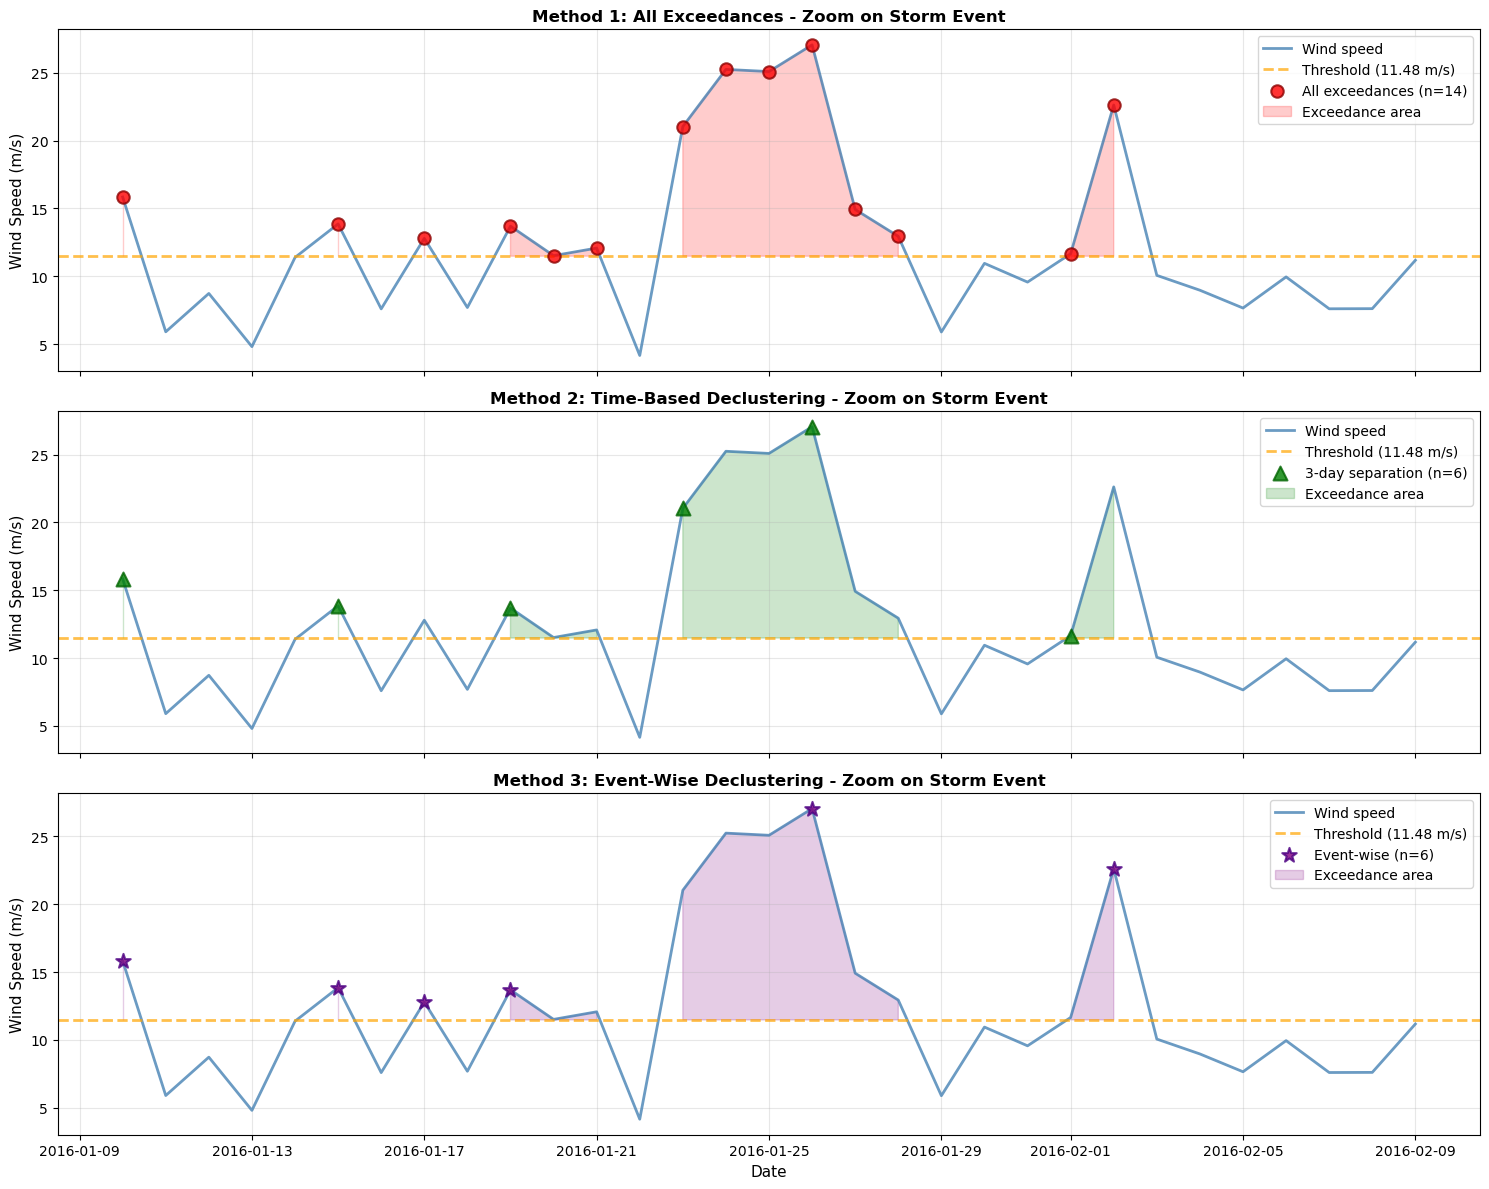


🔍 Detailed Storm Analysis:
Period shown: 2016-01-10 to 2016-02-09 (~1 month)
Storm duration: 6 consecutive days above threshold

Peaks identified in this window:
  • All exceedances: 14 peaks
  • 3-day separation: 6 peaks
  • Event-wise: 6 peak(s)

💡 Notice how:
   - All exceedances captures every day above threshold (may count same storm multiple times)
   - 3-day separation reduces but may still capture multiple peaks from one extended storm
   - Event-wise correctly identifies this as a single storm event with one representative peak


In [63]:
# Zoom in on a specific storm event to illustrate the differences
# Find a period with multiple consecutive exceedances
exceedance_mask = wind_speeds > threshold_90
consecutive_periods = []
in_period = False
period_start = None

for i, (date, exceeds) in enumerate(zip(dates, exceedance_mask)):
    if exceeds and not in_period:
        # Start of a new period
        period_start = i
        in_period = True
    elif not exceeds and in_period:
        # End of period
        consecutive_periods.append((period_start, i - 1))
        in_period = False

# If still in a period at the end
if in_period:
    consecutive_periods.append((period_start, len(dates) - 1))

# Find the longest consecutive period (most interesting storm)
longest_period = max(consecutive_periods, key=lambda x: x[1] - x[0])
storm_center = (longest_period[0] + longest_period[1]) // 2

# Extract 1 month window around this storm (±15 days)
window_days = 15
zoom_start = max(0, storm_center - window_days)
zoom_end = min(len(dates) - 1, storm_center + window_days)

zoom_dates = dates[zoom_start:zoom_end+1]
zoom_winds = wind_speeds[zoom_start:zoom_end+1]

# Filter peaks to this window
mask_all = (times_all >= zoom_dates[0]) & (times_all <= zoom_dates[-1])
mask_3days = (times_3days >= zoom_dates[0]) & (times_3days <= zoom_dates[-1])
mask_eventwise = (times_eventwise >= zoom_dates[0]) & (times_eventwise <= zoom_dates[-1])

zoom_peaks_all = peaks_all[mask_all]
zoom_times_all = times_all[mask_all]
zoom_peaks_3days = peaks_3days[mask_3days]
zoom_times_3days = times_3days[mask_3days]
zoom_peaks_eventwise = peaks_eventwise[mask_eventwise]
zoom_times_eventwise = times_eventwise[mask_eventwise]

# Create detailed zoom plot
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Plot 1: All exceedances
ax = axes[0]
ax.plot(zoom_dates, zoom_winds, linewidth=2, color='steelblue', label='Wind speed', alpha=0.8)
ax.axhline(threshold_90, color='orange', linestyle='--', linewidth=2, 
           label=f'Threshold ({threshold_90:.2f} m/s)', alpha=0.7)
ax.scatter(zoom_times_all, zoom_peaks_all, color='red', s=80, zorder=5, 
          label=f'All exceedances (n={len(zoom_peaks_all)})', alpha=0.8, edgecolors='darkred', linewidth=1.5)
ax.fill_between(zoom_dates, threshold_90, zoom_winds, 
                where=(zoom_winds > threshold_90), alpha=0.2, color='red', label='Exceedance area')
ax.set_ylabel('Wind Speed (m/s)', fontsize=11)
ax.set_title('Method 1: All Exceedances - Zoom on Storm Event', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: 3-day separation
ax = axes[1]
ax.plot(zoom_dates, zoom_winds, linewidth=2, color='steelblue', label='Wind speed', alpha=0.8)
ax.axhline(threshold_90, color='orange', linestyle='--', linewidth=2, 
           label=f'Threshold ({threshold_90:.2f} m/s)', alpha=0.7)
ax.scatter(zoom_times_3days, zoom_peaks_3days, color='green', s=100, zorder=5, 
          label=f'3-day separation (n={len(zoom_peaks_3days)})', alpha=0.8, marker='^', 
          edgecolors='darkgreen', linewidth=1.5)
ax.fill_between(zoom_dates, threshold_90, zoom_winds, 
                where=(zoom_winds > threshold_90), alpha=0.2, color='green', label='Exceedance area')
ax.set_ylabel('Wind Speed (m/s)', fontsize=11)
ax.set_title('Method 2: Time-Based Declustering - Zoom on Storm Event', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 3: Event-wise
ax = axes[2]
ax.plot(zoom_dates, zoom_winds, linewidth=2, color='steelblue', label='Wind speed', alpha=0.8)
ax.axhline(threshold_90, color='orange', linestyle='--', linewidth=2, 
           label=f'Threshold ({threshold_90:.2f} m/s)', alpha=0.7)
ax.scatter(zoom_times_eventwise, zoom_peaks_eventwise, color='purple', s=120, zorder=5, 
          label=f'Event-wise (n={len(zoom_peaks_eventwise)})', alpha=0.8, marker='*', 
          edgecolors='indigo', linewidth=1.5)
ax.fill_between(zoom_dates, threshold_90, zoom_winds, 
                where=(zoom_winds > threshold_90), alpha=0.2, color='purple', label='Exceedance area')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Wind Speed (m/s)', fontsize=11)
ax.set_title('Method 3: Event-Wise Declustering - Zoom on Storm Event', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Format x-axis
for ax in axes:
    ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

print(f"\n🔍 Detailed Storm Analysis:")
print(f"Period shown: {zoom_dates[0].date()} to {zoom_dates[-1].date()} (~1 month)")
print(f"Storm duration: {longest_period[1] - longest_period[0] + 1} consecutive days above threshold")
print(f"\nPeaks identified in this window:")
print(f"  • All exceedances: {len(zoom_peaks_all)} peaks")
print(f"  • 3-day separation: {len(zoom_peaks_3days)} peaks")
print(f"  • Event-wise: {len(zoom_peaks_eventwise)} peak(s)")
print(f"\n💡 Notice how:")
print(f"   - All exceedances captures every day above threshold (may count same storm multiple times)")
print(f"   - 3-day separation reduces but may still capture multiple peaks from one extended storm")
print(f"   - Event-wise correctly identifies this as a single storm event with one representative peak")

### Impact of Threshold Selection on Event Identification

Different thresholds will identify different numbers of events with varying characteristics. Let's explore how threshold choice affects the storm identification.

In [64]:
# Test different thresholds with event-wise declustering
percentiles = [85, 90, 95, 98]
threshold_results = {}

for p in percentiles:
    thresh = np.percentile(wind_speeds, p)
    peaks_evt, times_evt = extremes.peaks_over_threshold(
        threshold=thresh,
        event_wise=True
    )
    
    # Calculate event statistics
    event_durations = []
    series = pd.Series(wind_speeds, index=dates)
    
    for event_time in times_evt:
        # Find the consecutive period around this peak
        event_mask = series > thresh
        # Find the continuous block containing this event
        idx_loc = series.index.get_loc(event_time)
        
        # Expand left
        start_idx = idx_loc
        while start_idx > 0 and event_mask.iloc[start_idx - 1]:
            start_idx -= 1
        
        # Expand right
        end_idx = idx_loc
        while end_idx < len(series) - 1 and event_mask.iloc[end_idx + 1]:
            end_idx += 1
        
        duration = end_idx - start_idx + 1
        event_durations.append(duration)
    
    threshold_results[p] = {
        'threshold': thresh,
        'n_events': len(peaks_evt),
        'mean_peak': np.mean(peaks_evt),
        'max_peak': np.max(peaks_evt),
        'mean_duration': np.mean(event_durations) if event_durations else 0,
        'max_duration': np.max(event_durations) if event_durations else 0,
        'peaks': peaks_evt,
        'times': times_evt
    }

# Display results
print("Impact of Threshold on Event Characteristics (Event-Wise Declustering)")
print("=" * 90)
print(f"{'Percentile':<12} {'Threshold':<12} {'# Events':<12} {'Mean Peak':<12} {'Mean Duration':<15} {'Max Duration'}")
print("-" * 90)

for p in percentiles:
    res = threshold_results[p]
    print(f"{p}th{'':<9} {res['threshold']:<12.2f} {res['n_events']:<12} "
          f"{res['mean_peak']:<12.2f} {res['mean_duration']:<15.1f} {res['max_duration']} days")

print("\n💡 Key Observations:")
print("   • Higher thresholds → Fewer but more intense events")
print("   • Lower thresholds → More events, including weaker/shorter storms")
print("   • Event duration shows how long storms persist above threshold")

Impact of Threshold on Event Characteristics (Event-Wise Declustering)
Percentile   Threshold    # Events     Mean Peak    Mean Duration   Max Duration
------------------------------------------------------------------------------------------
85th          10.56        372          12.91        1.5             6 days
90th          11.48        276          13.61        1.3             6 days
95th          12.71        152          14.89        1.2             6 days
98th          14.33        58           17.29        1.3             5 days

💡 Key Observations:
   • Higher thresholds → Fewer but more intense events
   • Lower thresholds → More events, including weaker/shorter storms
   • Event duration shows how long storms persist above threshold



📊 Interpretation:
   Left: Trade-off between event frequency and intensity
   Right: Higher thresholds capture only the most persistent events


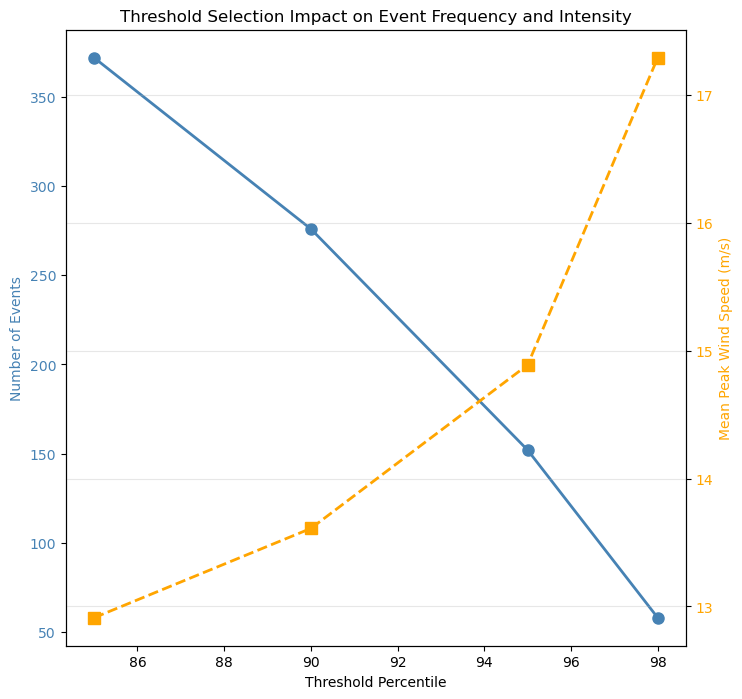

In [ ]:
# Visualize threshold impact
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Plot: Number of events vs threshold
thresholds = [threshold_results[p]['threshold'] for p in percentiles]
n_events = [threshold_results[p]['n_events'] for p in percentiles]
mean_peaks = [threshold_results[p]['mean_peak'] for p in percentiles]

ax_twin = ax.twinx()
line1 = ax.plot(percentiles, n_events, 'o-', color='steelblue', linewidth=2, 
                 markersize=8, label='Number of events')
line2 = ax_twin.plot(percentiles, mean_peaks, 's--', color='orange', linewidth=2, 
                      markersize=8, label='Mean peak intensity')

ax.set_xlabel('Threshold Percentile')
ax.set_ylabel('Number of Events', color='steelblue')
ax_twin.set_ylabel('Mean Peak Wind Speed (m/s)', color='orange')
ax.set_title('Threshold Selection Impact on Event Frequency and Intensity')
ax.tick_params(axis='y', labelcolor='steelblue')
ax_twin.tick_params(axis='y', labelcolor='orange')
ax_twin.grid(True, alpha=0.3)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

print("\n📊 Interpretation:")
print("   Left: Trade-off between event frequency and intensity")
print("   Right: Higher thresholds capture only the most persistent events")

### Comparing GPD Fits: Event-Wise vs Time-Based Declustering

Let's see how the choice of declustering method affects the fitted GPD distribution and return value estimates.

In [77]:
# Compare GPD fits with different declustering methods
threshold_compare = threshold_90

# Get peaks with both methods
peaks_time, times_time = extremes.peaks_over_threshold(threshold=threshold_compare, min_separation=3)
peaks_event, times_event = extremes.peaks_over_threshold(threshold=threshold_compare, event_wise=True)

# Fit GPD to exceedances from both methods
exceedances_time = peaks_time - threshold_compare
exceedances_event = peaks_event - threshold_compare

# Time-based declustering
proc_time = ma.read_data(exceedances_time)
pot_time = proc_time.get_extremes_analyzer(time_unit='years')
pot_time.fit_distribution('genpareto')

# Event-wise declustering
proc_event = ma.read_data(exceedances_event)
pot_event = proc_event.get_extremes_analyzer(time_unit='years')
pot_event.fit_distribution('genpareto')

# Compare parameters
print("GPD Parameter Comparison")
print("=" * 70)
print(f"Threshold: {threshold_compare:.2f} m/s (90th percentile)")
print(f"\n{'Method':<25} {'# Peaks':<12} {'Shape (ξ)':<12} {'Scale (σ)'}")
print("-" * 70)

params_time = pot_time.fitted_params
params_event = pot_event.fitted_params

print(f"{'3-day separation':<25} {len(peaks_time):<12} {params_time[0]:<12.4f} {params_time[2]:.4f}")
print(f"{'Event-wise':<25} {len(peaks_event):<12} {params_event[0]:<12.4f} {params_event[2]:.4f}")

# Calculate return values
print("\n\nReturn Value Comparison (m/s)")
print("=" * 70)
print(f"{'Return Period':<20} {'3-day separation':<20} {'Event-wise':<20} {'Difference'}")
print("-" * 70)

rate_time = len(peaks_time) / extremes.time_span
rate_event = len(peaks_event) / extremes.time_span

for T in [10, 50, 100]:
    # Time-based
    prob_time = 1.0 / (rate_time * T)
    if prob_time < 1.0:
        rv_time = threshold_compare + pot_time.ppf(1 - prob_time)
    else:
        rv_time = np.nan
    
    # Event-wise
    prob_event = 1.0 / (rate_event * T)
    if prob_event < 1.0:
        rv_event = threshold_compare + pot_event.ppf(1 - prob_event)
    else:
        rv_event = np.nan
    
    if not np.isnan(rv_time) and not np.isnan(rv_event):
        diff = rv_event - rv_time
        print(f"{T} years{'':<13} {rv_time:<20.2f} {rv_event:<20.2f} {diff:+.2f}")

print("\n💡 Key Insights:")
print("   • Event-wise declustering reduces peak count (fewer independent events)")
print("   • This affects the exceedance rate and thus return value estimates")
print("   • Event-wise is more physically meaningful for clustered extremes (storms)")
print("   • Time-based separation is simpler but may over-count dependent events")

GPD Parameter Comparison
Threshold: 11.48 m/s (90th percentile)

Method                    # Peaks      Shape (ξ)    Scale (σ)
----------------------------------------------------------------------
3-day separation          253          0.1114       1.6107
Event-wise                276          0.1607       1.7784


Return Value Comparison (m/s)
Return Period        3-day separation     Event-wise           Difference
----------------------------------------------------------------------
10 years              23.81                27.73                +3.92
50 years              29.07                35.79                +6.72
100 years              31.64                39.96                +8.32

💡 Key Insights:
   • Event-wise declustering reduces peak count (fewer independent events)
   • This affects the exceedance rate and thus return value estimates
   • Event-wise is more physically meaningful for clustered extremes (storms)
   • Time-based separation is simpler but may over-count

/home/daniloceano/Documents/Programs_and_scripts/MagicA/magica/core/extremes_analyzer.py:113: UserWarning: No time information provided. Assuming uniform time spacing. Return periods will be in units of observation count.
  warnings.warn(


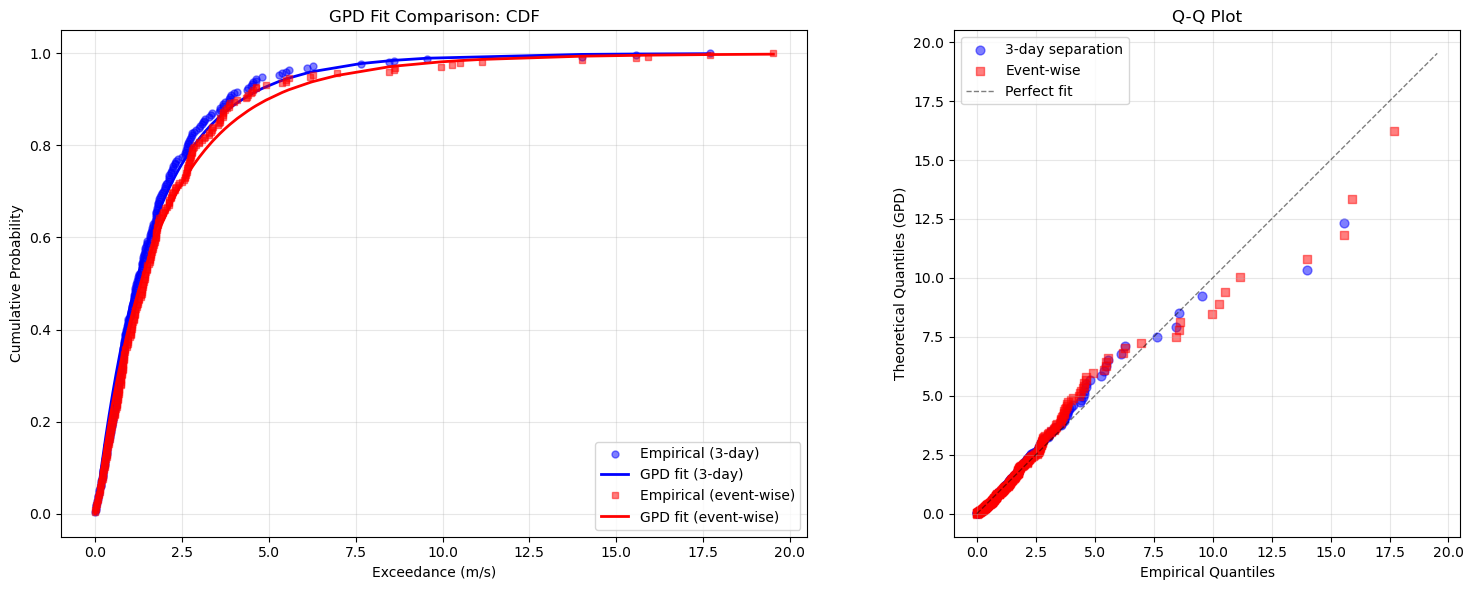


📊 Plot Interpretation:
   Left: Both methods show good GPD fits (empirical and theoretical CDFs align)
   Right: Q-Q plot shows how well data follows GPD (points near diagonal = good fit)


In [78]:
# Visualize the GPD fits
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Empirical vs fitted CDF
sorted_exc_time = np.sort(exceedances_time)
sorted_exc_event = np.sort(exceedances_event)

emp_cdf_time = np.arange(1, len(sorted_exc_time) + 1) / len(sorted_exc_time)
emp_cdf_event = np.arange(1, len(sorted_exc_event) + 1) / len(sorted_exc_event)

theo_cdf_time = pot_time.cdf(sorted_exc_time)
theo_cdf_event = pot_event.cdf(sorted_exc_event)

ax1.plot(sorted_exc_time, emp_cdf_time, 'o', color='blue', alpha=0.5, 
         markersize=5, label='Empirical (3-day)')
ax1.plot(sorted_exc_time, theo_cdf_time, '-', color='blue', linewidth=2, 
         label='GPD fit (3-day)')
ax1.plot(sorted_exc_event, emp_cdf_event, 's', color='red', alpha=0.5, 
         markersize=5, label='Empirical (event-wise)')
ax1.plot(sorted_exc_event, theo_cdf_event, '-', color='red', linewidth=2, 
         label='GPD fit (event-wise)')
ax1.set_xlabel('Exceedance (m/s)')
ax1.set_ylabel('Cumulative Probability')
ax1.set_title('GPD Fit Comparison: CDF')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Q-Q plot
ax2.scatter(sorted_exc_time, pot_time.ppf(emp_cdf_time), 
           color='blue', alpha=0.5, s=40, label='3-day separation')
ax2.scatter(sorted_exc_event, pot_event.ppf(emp_cdf_event), 
           color='red', alpha=0.5, s=40, label='Event-wise', marker='s')

# Add diagonal line
max_val = max(np.max(sorted_exc_time), np.max(sorted_exc_event))
ax2.plot([0, max_val], [0, max_val], 'k--', linewidth=1, alpha=0.5, label='Perfect fit')

ax2.set_xlabel('Empirical Quantiles')
ax2.set_ylabel('Theoretical Quantiles (GPD)')
ax2.set_title('Q-Q Plot')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

print("\n📊 Plot Interpretation:")
print("   Left: Both methods show good GPD fits (empirical and theoretical CDFs align)")
print("   Right: Q-Q plot shows how well data follows GPD (points near diagonal = good fit)")

In [79]:
# Calculate return values from both methods
comparison_periods = [5, 10, 20, 50, 100]

gev_values = [maxima_extremes.return_value(T) for T in comparison_periods]

# POT return values
pot_values = []
for T in comparison_periods:
    prob = 1.0 / (exceedance_rate * T)
    if prob < 1.0:
        exceedance_quantile = pot_extremes.ppf(1 - prob)
        pot_values.append(threshold + exceedance_quantile)
    else:
        pot_values.append(np.nan)

# Comparison table
print("Method Comparison: Block Maxima (GEV) vs POT (GPD)")
print("=" * 80)
print(f"{'Return Period':<15} {'GEV (m/s)':<15} {'GPD (m/s)':<15} {'Difference':<15} {'% Diff'}")
print("-" * 80)

for T, gev_val, pot_val in zip(comparison_periods, gev_values, pot_values):
    if not np.isnan(pot_val):
        diff = pot_val - gev_val
        pct_diff = (diff / gev_val) * 100
        print(f"{T} years{'':<8} {gev_val:<15.2f} {pot_val:<15.2f} {diff:<+15.2f} {pct_diff:+.1f}%")
    else:
        print(f"{T} years{'':<8} {gev_val:<15.2f} {'N/A':<15} {'N/A':<15} {'N/A'}")

print("\n📊 Method Selection Guidelines:")
print("\nBlock Maxima (GEV):")
print("  ✓ More robust, classical approach")
print("  ✓ Less sensitive to threshold selection")
print("  ✓ Better for data with clear seasonal structure")
print("  ✗ Uses less data (only one value per block)")
print("  ✗ Requires long time series for reliability")
print("\nPeaks Over Threshold (GPD):")
print("  ✓ More efficient, uses more extreme data")
print("  ✓ Better for short time series")
print("  ✓ Can adapt to changing extreme behavior")
print("  ✗ Sensitive to threshold choice")
print("  ✗ Requires careful declustering")
print("  ✗ More complex implementation")

Method Comparison: Block Maxima (GEV) vs POT (GPD)
Return Period   GEV (m/s)       GPD (m/s)       Difference      % Diff
--------------------------------------------------------------------------------
5 years         26.85           24.76           -2.10           -7.8%
10 years         29.04           28.44           -0.60           -2.1%
20 years         30.74           32.91           +2.17           +7.1%
50 years         32.46           40.30           +7.84           +24.1%
100 years         33.48           47.29           +13.80          +41.2%

📊 Method Selection Guidelines:

Block Maxima (GEV):
  ✓ More robust, classical approach
  ✓ Less sensitive to threshold selection
  ✓ Better for data with clear seasonal structure
  ✗ Uses less data (only one value per block)
  ✗ Requires long time series for reliability

Peaks Over Threshold (GPD):
  ✓ More efficient, uses more extreme data
  ✓ Better for short time series
  ✓ Can adapt to changing extreme behavior
  ✗ Sensitive to th

## Visualizing Both Approaches Side-by-Side

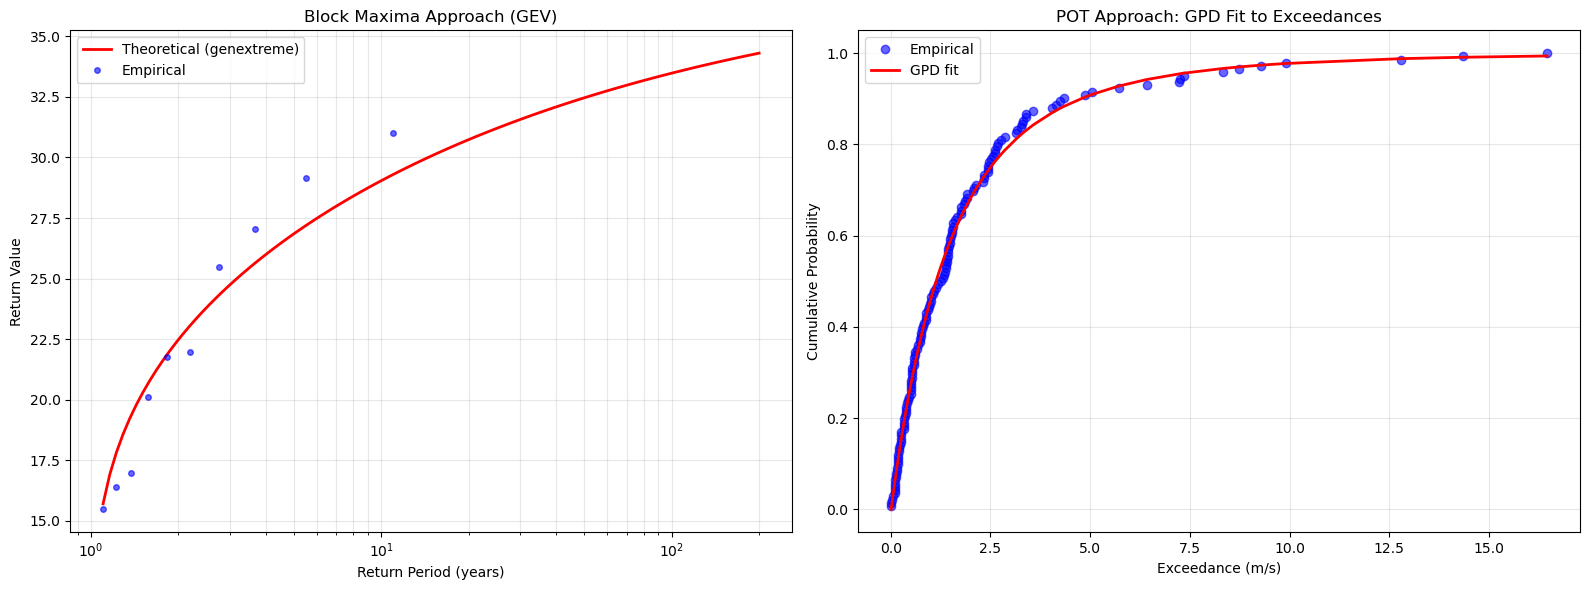

In [80]:
# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: GEV return levels
maxima_extremes.plot_return_levels(
    ax=ax1,
    return_periods=np.logspace(np.log10(1.1), np.log10(200), 100),
    confidence_level=0.95,
    title='Block Maxima Approach (GEV)'
)

# Plot 2: Exceedance distribution (GPD)
sorted_exceedances = np.sort(exceedances)
empirical_cdf = np.arange(1, len(sorted_exceedances) + 1) / len(sorted_exceedances)
theoretical_cdf = pot_extremes.cdf(sorted_exceedances)

ax2.plot(sorted_exceedances, empirical_cdf, 'bo', markersize=6, alpha=0.6, label='Empirical')
ax2.plot(sorted_exceedances, theoretical_cdf, 'r-', linewidth=2, label='GPD fit')
ax2.set_xlabel('Exceedance (m/s)')
ax2.set_ylabel('Cumulative Probability')
ax2.set_title('POT Approach: GPD Fit to Exceedances')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Advanced: Monthly and Seasonal Block Maxima

Besides annual maxima, we can extract maxima from other time blocks.

In [81]:
# Extract monthly maxima
monthly_maxima = extremes.extract_block_maxima(block_size='M', method='max')

print(f"Monthly Maxima Analysis:")
print(f"Number of months: {len(monthly_maxima[1])}")
print(f"Mean monthly maximum: {np.mean(list(monthly_maxima[0])):.2f} m/s")
print(f"\nFirst 12 months:")
for max_wind, month in zip(monthly_maxima[0][:12], monthly_maxima[1][:12]):
    print(f"{month.month}: {max_wind:.2f} m/s")

Monthly Maxima Analysis:
Number of months: 120
Mean monthly maximum: 13.40 m/s

First 12 months:
1: 15.47 m/s
2: 15.07 m/s
3: 15.03 m/s
4: 10.56 m/s
5: 10.01 m/s
6: 9.86 m/s
7: 7.64 m/s
8: 8.94 m/s
9: 12.55 m/s
10: 9.83 m/s
11: 13.44 m/s
12: 14.33 m/s


/home/daniloceano/Documents/Programs_and_scripts/MagicA/magica/core/extremes_analyzer.py:460: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  resampled = series.resample(block_size).max()


In [82]:
monthly_maxima

(array([15.47471679, 15.07479826, 15.02877653, 10.55705581, 10.00709021,
         9.86265125,  7.64222178,  8.94051386, 12.5520534 ,  9.82719807,
        13.43554726, 14.32832664, 16.96210148, 14.19772591, 14.61696357,
        13.05446575, 10.92222024, 11.77431555, 21.43229129,  8.8559514 ,
        12.12378269, 13.30120898, 31.00524042, 16.11340243, 14.36866988,
        13.64949057, 14.23849738, 13.24443348,  9.41404984,  7.61720663,
         8.8456436 ,  8.62818935, 10.18005466, 12.40131518, 16.96404217,
        16.86636793, 17.75387682, 12.57997485, 14.27202794, 15.27865226,
        10.90722767,  8.39165259,  9.07484006, 10.7484446 , 10.62181582,
        12.16499382, 21.75032119, 14.850602  , 19.92607348, 14.21094858,
        13.26922496, 10.84752116, 11.69727717, 10.47763436,  9.32231068,
         9.13605056, 12.50616378, 21.98728031, 12.83636776, 15.05835099,
        16.00350195, 16.1002818 , 15.88255493, 20.10772396, 12.93851257,
         8.38791272,  8.70847773,  8.2943145 , 10.4

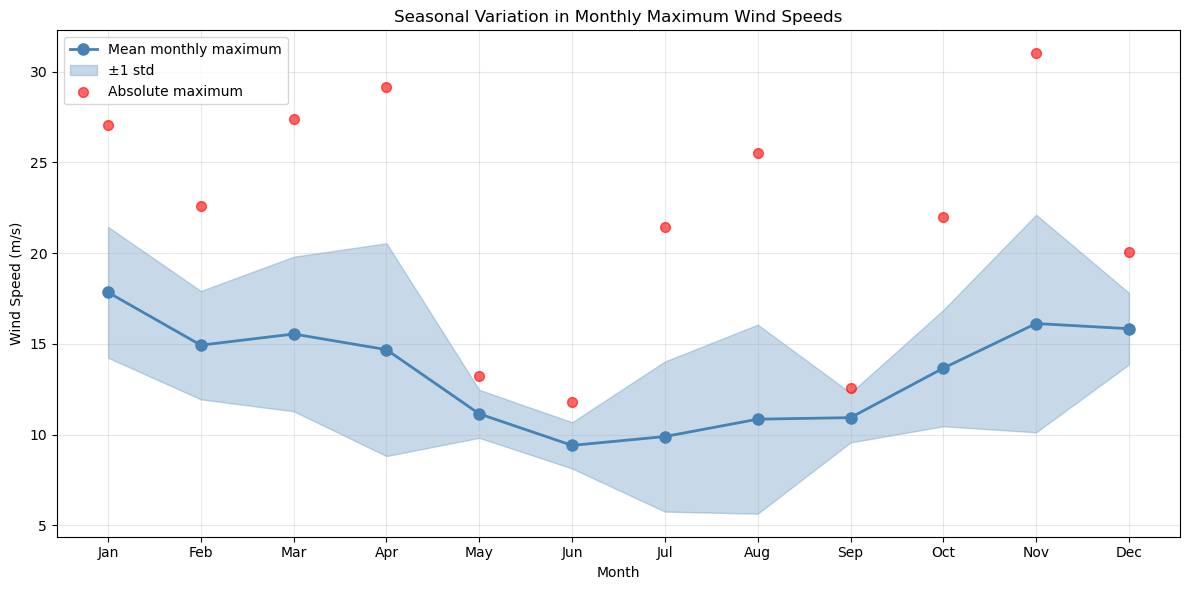


Most extreme month on average: Jan (17.83 m/s)
Least extreme month on average: Jun (9.40 m/s)


In [83]:
# Visualize seasonal variation in extremes
# Convert monthly maxima to DataFrame for easier analysis
# monthly_maxima is a tuple of (values, timestamps)
monthly_values, monthly_dates = monthly_maxima

monthly_df = pd.DataFrame({
    'date': monthly_dates,
    'max_wind': monthly_values
})
monthly_df['month'] = monthly_df['date'].dt.month
monthly_df['month_name'] = monthly_df['date'].dt.strftime('%b')

# Calculate monthly statistics
monthly_stats = monthly_df.groupby(['month', 'month_name'])['max_wind'].agg(['mean', 'std', 'min', 'max']).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

# Plot mean with error bars
months = monthly_stats['month'].values
means = monthly_stats['mean'].values
stds = monthly_stats['std'].values

ax.plot(months, means, 'o-', linewidth=2, markersize=8, color='steelblue', label='Mean monthly maximum')
ax.fill_between(months, means - stds, means + stds, alpha=0.3, color='steelblue', label='±1 std')
ax.scatter(months, monthly_stats['max'], color='red', s=50, zorder=5, alpha=0.6, label='Absolute maximum')

ax.set_xlabel('Month')
ax.set_ylabel('Wind Speed (m/s)')
ax.set_title('Seasonal Variation in Monthly Maximum Wind Speeds')
ax.set_xticks(months)
ax.set_xticklabels(monthly_stats['month_name'])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find the most extreme month
most_extreme_month = monthly_stats.loc[monthly_stats['mean'].idxmax()]
print(f"\nMost extreme month on average: {most_extreme_month['month_name']} ({most_extreme_month['mean']:.2f} m/s)")
print(f"Least extreme month on average: {monthly_stats.loc[monthly_stats['mean'].idxmin(), 'month_name']} "
      f"({monthly_stats['mean'].min():.2f} m/s)")

## Goodness-of-Fit Assessment for Extreme Value Distributions

Let's evaluate how well our distributions fit the extreme data.

In [84]:
# Goodness-of-fit for GEV (annual maxima)
print("Goodness-of-Fit Assessment:")
print("=" * 60)
print("\nBlock Maxima (GEV):")

ks_gev = maxima_extremes.goodness_of_fit('ks')
print(f"  Kolmogorov-Smirnov Test:")
print(f"    Statistic: {ks_gev['ks_statistic']:.6f}")
print(f"    P-value: {ks_gev['p_value']:.6f}")
print(f"    Result: {'Good fit ✓' if ks_gev['p_value'] > 0.05 else 'Poor fit ✗'} (α = 0.05)")

rmse_gev = maxima_extremes.goodness_of_fit('rmse')
print(f"  RMSE: {rmse_gev:.6f}")

# Goodness-of-fit for GPD (exceedances)
print("\nPeaks Over Threshold (GPD):")

ks_gpd = pot_extremes.goodness_of_fit('ks')
print(f"  Kolmogorov-Smirnov Test:")
print(f"    Statistic: {ks_gpd['ks_statistic']:.6f}")
print(f"    P-value: {ks_gpd['p_value']:.6f}")
print(f"    Result: {'Good fit ✓' if ks_gpd['p_value'] > 0.05 else 'Poor fit ✗'} (α = 0.05)")

rmse_gpd = pot_extremes.goodness_of_fit('rmse')
print(f"  RMSE: {rmse_gpd:.6f}")

print("\n💡 Note: Small sample sizes in extreme value analysis often result in")
print("   lower statistical power. Visual inspection of Q-Q plots and return")
print("   level plots is equally important.")

Goodness-of-Fit Assessment:

Block Maxima (GEV):
  Kolmogorov-Smirnov Test:
    Statistic: 0.159776
    P-value: 0.926496
    Result: Good fit ✓ (α = 0.05)
  RMSE: 0.079543

Peaks Over Threshold (GPD):
  Kolmogorov-Smirnov Test:
    Statistic: 0.047733
    P-value: 0.887153
    Result: Good fit ✓ (α = 0.05)
  RMSE: 0.015191

💡 Note: Small sample sizes in extreme value analysis often result in
   lower statistical power. Visual inspection of Q-Q plots and return
   level plots is equally important.


## Summary Statistics and Report

Let's generate a comprehensive summary of the extreme value analysis.

In [85]:
# Get summary statistics from ExtremesAnalyzer
summary = extremes.get_summary_statistics()

print("EXTREME VALUE ANALYSIS SUMMARY REPORT")
print("=" * 80)
print(f"\nDataset Information:")
print(f"  Period: {dates[0].date()} to {dates[-1].date()}")
print(f"  Duration: {extremes.time_span:.2f} years")
print(f"  Total observations: {summary['n_observations']}")
print(f"  Time unit: {summary['time_unit']}")

print(f"\nData Statistics:")
print(f"  Mean: {summary['mean']:.2f} m/s")
print(f"  Std Dev: {summary['std']:.2f} m/s")
print(f"  Minimum: {summary['min']:.2f} m/s")
print(f"  Maximum: {summary['max']:.2f} m/s")
print(f"  95th percentile: {summary['percentile_95']:.2f} m/s")
print(f"  99th percentile: {summary['percentile_99']:.2f} m/s")

if summary['distribution_name']:
    print(f"\nFitted Distribution: {summary['distribution_name']}")
    print(f"  Parameters: {summary['distribution_params']}")

print(f"\nBlock Maxima Analysis:")
print(f"  Annual maxima: {len(annual_maxima)} years")
print(f"  Mean annual maximum: {np.mean(maxima_values):.2f} m/s")
print(f"  GEV shape parameter: {params[0]:.4f}")

print(f"\nPOT Analysis:")
print(f"  Threshold: {threshold:.2f} m/s (95th percentile)")
print(f"  Number of peaks: {len(peaks)}")
print(f"  Exceedance rate: {exceedance_rate:.2f} peaks/year")
print(f"  GPD shape parameter: {gpd_params[0]:.4f}")

print(f"\nDesign Wind Speeds (GEV):")
for T in [10, 50, 100]:
    rv = maxima_extremes.return_value(T)
    print(f"  {T}-year return value: {rv:.2f} m/s")

print("\n" + "=" * 80)

EXTREME VALUE ANALYSIS SUMMARY REPORT

Dataset Information:
  Period: 2010-01-01 to 2019-12-31
  Duration: 10.00 years
  Total observations: 3652
  Time unit: years

Data Statistics:
  Mean: 7.44 m/s
  Std Dev: 3.08 m/s
  Minimum: 1.86 m/s
  Maximum: 31.01 m/s
  95th percentile: 12.71 m/s
  99th percentile: 15.93 m/s

Block Maxima Analysis:
  Annual maxima: 10 years
  Mean annual maximum: 22.54 m/s
  GEV shape parameter: 0.2926

POT Analysis:
  Threshold: 12.71 m/s (95th percentile)
  Number of peaks: 142
  Exceedance rate: 14.21 peaks/year
  GPD shape parameter: 0.2779

Design Wind Speeds (GEV):
  10-year return value: 29.04 m/s
  50-year return value: 32.46 m/s
  100-year return value: 33.48 m/s

  50-year return value: 32.46 m/s
  100-year return value: 33.48 m/s



## Best Practices and Recommendations

### When to Use Extreme Value Analysis:

1. **Design of structures** (wind turbines, buildings, bridges)
2. **Risk assessment** (insurance, safety planning)
3. **Climate studies** (return periods of extreme weather)
4. **Ocean engineering** (extreme wave heights)
5. **Hydrology** (flood return periods)

### Key Guidelines:

1. **Data Requirements:**
   - Minimum 10-30 years for reliable annual maxima analysis
   - Data should be stationary (no long-term trends)
   - Quality control is crucial for extreme values

2. **Method Selection:**
   - **Use Block Maxima (GEV)** when:
     - You have long time series (>20 years)
     - Data has strong seasonal patterns
     - Simplicity and robustness are priorities
   
   - **Use POT (GPD)** when:
     - Time series is shorter (<20 years)
     - You want to use more extreme data
     - Extremes don't follow seasonal patterns

3. **Threshold Selection (POT):**
   - Too low: violates GPD assumptions (not in tail)
   - Too high: insufficient data for fitting
   - Start with 90-95th percentile, adjust based on diagnostics

4. **Declustering:**
   - Essential for POT to ensure independence
   - **Time-based separation**: 
     - Use when events are clearly separated
     - Typical separation: 3-7 days for storms, depends on phenomenon
     - Simple but may over-count dependent events
   - **Event-wise declustering** (recommended for clustered extremes):
     - Groups consecutive exceedances as single events
     - Extracts maximum from each event
     - More physically meaningful for storms, heat waves, etc.
     - Use `event_wise=True` parameter
   - Compare both methods to validate independence assumption
   - Use autocorrelation analysis to guide selection

5. **Return Period Interpretation:**
   - T-year return value ≠ maximum in T years
   - It's the value exceeded on average once every T years
   - Annual exceedance probability = 1/T

6. **Uncertainty:**
   - Extrapolation beyond observed data is uncertain
   - Always report confidence intervals
   - Be especially cautious with return periods > 2 × record length

7. **Model Validation:**
   - Check return level plots visually
   - Compare multiple models (GEV, Gumbel, Weibull)
   - Consider physical plausibility of results

### Common Pitfalls to Avoid:

- ❌ Using insufficient data length
- ❌ Ignoring data quality issues
- ❌ Not checking for trends/non-stationarity
- ❌ Over-extrapolating beyond data range
- ❌ Forgetting to decluster POT peaks
- ❌ Ignoring seasonal effects
- ❌ Not validating model assumptions
- ❌ Using time-based separation for highly clustered events

### Recommended Workflow:

```python
# 1. Load time series data (pandas Series with datetime index)
processor = ma.read_data(your_series)

# 2. Create extremes analyzer
extremes = processor.get_extremes_analyzer(time_unit='years')

# 3. Block Maxima approach
annual_maxima = extremes.extract_block_maxima(block_size='year')
maxima_processor = ma.read_data(list(annual_maxima.values()))
maxima_extremes = maxima_processor.get_extremes_analyzer(time_unit='years')
maxima_extremes.fit_distribution('genextreme')

# 4. Calculate design values
rv_50 = maxima_extremes.return_value(50)

# 5. Visualize and validate
maxima_extremes.plot_return_levels()

# 6. Compare with POT if needed
# Option A: Time-based declustering
peaks, peak_times = extremes.peaks_over_threshold(
    threshold=np.percentile(your_data, 95),
    min_separation=3
)

# Option B: Event-wise declustering (recommended for clustered events)
peaks, peak_times = extremes.peaks_over_threshold(
    threshold=np.percentile(your_data, 95),
    event_wise=True
)
```

## Further Reading

### Key References:

1. **Coles, S. (2001).** *An Introduction to Statistical Modeling of Extreme Values.*  
   Springer. (The definitive textbook on extreme value theory)

2. **Beirlant, J., et al. (2004).** *Statistics of Extremes: Theory and Applications.*  
   Wiley.

3. **Gumbel, E.J. (1958).** *Statistics of Extremes.*  
   Columbia University Press. (Classic text)

4. **Serinaldi, F. & Kilsby, C.G. (2014).**  
   "Rainfall extremes: Toward reconciliation after the battle of distributions."  
   *Water Resources Research*, 50(1), 336-352.

### Online Resources:

- **R package 'extRemes'**: Excellent documentation and examples
- **Python package 'pyextremes'**: Modern Python implementation
- **NCAR's EVA Tutorial**: Practical guide for climate data

### MagicA Documentation:

- For more on distributions: See the AutoFitter tutorial
- For Monte Carlo analysis: See the Monte Carlo stability tutorial
- API reference: Check the ExtremesAnalyzer documentation